In [1]:
# identificador: 145236

# Tarefa 4 - Random Forest com valores ausentes e K-means

Quarta tarefa avaliada da disciplina **Técnicas e Algoritmos em Ciência de Dados**.

Esta versão tem duas partes:

1. [Random Forest com valores ausentes](#Classification) (60%)
2. [Agrupamento com K-means](#K-Means) (40%)

Use o mesmo identificador aleatório de 6 dígitos usado nas tarefas anteriores e escreva-o na primeira célula do seu notebook submetido.

Você pode usar `numpy`, `pandas`, `matplotlib` e métricas de avaliação como AUROC. Você **não pode** usar implementações prontas de árvore de decisão, Random Forest, K-means ou ferramentas prontas de busca automática de parâmetros. Qualquer função auxiliar deve estar dentro deste notebook.


In [2]:
import math

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except ModuleNotFoundError:
    plt = None
    PLOTTING_AVAILABLE = False
    print("matplotlib não está instalado neste ambiente; ele será necessário para gerar os gráficos pedidos.")

try:
    display
except NameError:
    def display(obj):
        print(obj)


def roc_auc_score(y_true, y_score):
    """Calcula AUROC para rótulos binários, com tratamento correto de empates."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    positive = y_true == 1
    negative = y_true == 0
    n_pos = int(positive.sum())
    n_neg = int(negative.sum())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUROC requer exemplos das duas classes.")

    order = np.argsort(y_score, kind="mergesort")
    sorted_scores = y_score[order]
    ranks = np.empty(len(y_score), dtype=float)
    start = 0
    while start < len(y_score):
        end = start + 1
        while end < len(y_score) and sorted_scores[end] == sorted_scores[start]:
            end += 1
        average_rank = (start + 1 + end) / 2.0
        ranks[order[start:end]] = average_rank
        start = end

    rank_sum_pos = ranks[positive].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


<a id="Classification"></a>
## Parte 1 - Random Forest com valores ausentes (valor: 60%)

Você usará o arquivo `horse_colic_missing.csv`, baseado no conjunto Horse Colic. O alvo é `surgical_lesion`, em que `1` indica que o caso tinha lesão cirúrgica e `0` indica que não tinha.

Use apenas os atributos clínicos pré-desfecho listados abaixo. Não use `surgery`, `hospital_number`, `outcome`, códigos de lesão, `cp_data` ou outros campos que funcionem como identificadores, tratamento, desfecho ou vazamento de informação.

### Objetivo

Você pode reutilizar e adaptar suas implementações anteriores de árvore de decisão e Random Forest. O foco desta tarefa é modificar as árvores da floresta para lidar com valores ausentes durante a escolha das divisões, durante o treinamento e durante a predição.

### Estratégias obrigatórias para valores ausentes

Compare Florestas Aleatórias que diferem principalmente na forma como suas árvores tratam valores ausentes:

1. **Baseline simples de pré-processamento**: implemente uma referência simples, como imputação por mediana/moda aprendida apenas no treino. Essa estratégia serve como baseline.
2. **Roteamento fracionário por frequência de ramo**: ao avaliar uma divisão em um nó, use apenas os exemplos com valor observado naquele atributo para estimar as probabilidades dos ramos:

   ```text
   p_left = n_left_observed / n_observed
   p_right = n_right_observed / n_observed
   ```

   Os exemplos com valor ausente devem ser enviados para os dois filhos com esses pesos. A entropia, o ganho de informação e a frequência das classes nas folhas devem usar pesos: sempre que uma fórmula envolver contagem de exemplos, substitua a contagem pela soma dos pesos.

### O que entregar nesta parte

1. Carregue o conjunto de dados e descreva a fração de valores ausentes em cada atributo.
2. Faça a divisão treino/validação/teste com proporção 70/15/15 e `seed = 13`.
3. Adapte a árvore de decisão para usar pesos de amostras em entropia, ganho de informação e probabilidade da classe positiva nas folhas.
4. Armazene em cada nó interno as probabilidades de ramo estimadas a partir dos exemplos observados.
5. Implemente a predição para exemplos com valores ausentes usando o roteamento fracionário por frequência de ramo.
6. Implemente a Random Forest com bootstrap, subconjunto aleatório de atributos e agregação por média das probabilidades positivas ou média dos votos binários.
7. Escolha manualmente poucas combinações de hiperparâmetros usando AUROC na validação. Use `num_trees` entre 5 e 20 e profundidade máxima não superior a 5.
8. Treine novamente com treino + validação usando a melhor combinação de parâmetros e reporte acurácia com limiar 0.5 e AUROC no teste.
9. Compare as duas estratégias em uma tabela final e discuta qual funcionou melhor.


In [3]:
SEED = 13
TARGET = "surgical_lesion"
FEATURE_COLUMNS = [
    "age",
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "temperature_of_extremities",
    "peripheral_pulse",
    "mucous_membranes",
    "capillary_refill_time",
    "pain",
    "peristalsis",
    "abdominal_distension",
    "nasogastric_tube",
    "nasogastric_reflux",
    "nasogastric_reflux_ph",
    "rectal_exam_feces",
    "abdomen",
    "packed_cell_volume",
    "total_protein",
    "abdominocentesis_appearance",
    "abdomcentesis_total_protein",
]
NUMERIC_COLUMNS = {
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "nasogastric_reflux_ph",
    "packed_cell_volume",
    "total_protein",
    "abdomcentesis_total_protein",
}
CATEGORICAL_COLUMNS = [col for col in FEATURE_COLUMNS if col not in NUMERIC_COLUMNS]


df = pd.read_csv("../../data/horse_colic_missing.csv")
display(df.head())
missing_summary = df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
display(missing_summary)


,source_split,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,surgical_lesion
0,uci_train_file,1,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,...,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,0
1,uci_train_file,1,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,...,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,0
2,uci_train_file,1,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,...,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,0
3,uci_train_file,9,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,...,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,1
4,uci_train_file,1,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,0


,missing_fraction
nasogastric_reflux_ph,0.812500
abdomcentesis_total_protein,0.638587
abdominocentesis_appearance,0.527174
abdomen,0.388587
nasogastric_reflux,0.361413
nasogastric_tube,0.355978
rectal_exam_feces,0.347826
peripheral_pulse,0.225543
respiratory_rate,0.192935
rectal_temperature,0.187500


In [4]:
df[FEATURE_COLUMNS].dtypes 
# apenas atributos pre-desfecho
# source_split é string, mas não está em FEATURE_COLUMNS
# todas as outras são números e podem ser tratados

age                              int64
rectal_temperature             float64
pulse                          float64
respiratory_rate               float64
temperature_of_extremities     float64
peripheral_pulse               float64
mucous_membranes               float64
capillary_refill_time          float64
pain                           float64
peristalsis                    float64
abdominal_distension           float64
nasogastric_tube               float64
nasogastric_reflux             float64
nasogastric_reflux_ph          float64
rectal_exam_feces              float64
abdomen                        float64
packed_cell_volume             float64
total_protein                  float64
abdominocentesis_appearance    float64
abdomcentesis_total_protein    float64
dtype: object

In [5]:
def stratified_split(df, target=TARGET, train_size=0.70, val_size=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for _, group in df.groupby(target):
        idx = group.index.to_numpy()
        idx = rng.permutation(idx)
        n = len(idx)
        n_train = int(round(train_size * n))
        n_val = int(round(val_size * n))
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])
    return (
        df.loc[train_idx].sample(frac=1, random_state=seed).reset_index(drop=True),
        df.loc[val_idx].sample(frac=1, random_state=seed + 1).reset_index(drop=True),
        df.loc[test_idx].sample(frac=1, random_state=seed + 2).reset_index(drop=True),
    )


In [6]:
train_df, val_df, test_df = stratified_split(df)
train_y = train_df[TARGET].to_numpy(dtype=int)
val_y = val_df[TARGET].to_numpy(dtype=int)
test_y = test_df[TARGET].to_numpy(dtype=int)

print("Tamanhos treino/validação/teste:", len(train_df), len(val_df), len(test_df))
print("Distribuição do alvo no treino:", train_df[TARGET].value_counts(normalize=True).sort_index().to_dict())
print("Distribuição do alvo na validação:", val_df[TARGET].value_counts(normalize=True).sort_index().to_dict())
print("Distribuição do alvo no teste:", test_df[TARGET].value_counts(normalize=True).sort_index().to_dict())


Tamanhos treino/validação/teste: 257 55 56
Distribuição do alvo no treino: {0: 0.36964980544747084, 1: 0.6303501945525292}
Distribuição do alvo na validação: {0: 0.36363636363636365, 1: 0.6363636363636364}
Distribuição do alvo no teste: {0: 0.375, 1: 0.625}


### Árvore de decisão ponderada

Implemente abaixo a adaptação da árvore de decisão. Sua implementação deve incluir:

- entropia ponderada;
- ganho de informação ponderado;
- probabilidade positiva ponderada em cada folha;
- escolha de divisões ignorando valores ausentes apenas para calcular as frequências observadas dos ramos;
- envio fracionário dos exemplos ausentes para os dois filhos;
- armazenamento de `p_left` e `p_right` em cada nó interno para uso na predição.


In [7]:
# Escreva aqui a implementação da árvore de decisão ponderada e do
# roteamento fracionário por frequência de ramo.

class DecisionTree:
    def __init__(self, min_samples=2, max_depth=np.inf, regression=True):
        self.min_samples = min_samples
        self.max_depth = max_depth 

        self.regression = regression
        if (regression):    self.criteria = self.reg_criteria
        else:               self.criteria = self.cla_criteria

    def reg_criteria(self, target, weights):
        """SSE of a region for regression estimator"""

        if target.size == 0: return np.inf
        if weights.sum() == 0: return 0.0

        media = (target * weights).sum() / (weights).sum()
        return np.sum(weights * (target - media) ** 2)
    
    def cla_criteria(self, target, weights):
        """entropy of a region for classification estimator"""

        if target.size == 0: return 0

        classes = np.unique(target)
        pmk = np.array([weights[target == c].sum() for c in classes])
        pmk = pmk / pmk.sum()
        pmk = pmk[pmk > 0]
        entropy = (-1) * pmk * np.log2(pmk)
        return entropy.sum()
    
    def split_region(self, region, weights, feature_idx, tau):
        """
        Given a region, splits it based on the feature indicated by
        `feature_index`, the region will be split in two, where
        one side will contain all points with the feature with values 
        lower than `tau`, and the other split will contain the 
        remaining datapoints.
        """

        feature = region[:, feature_idx]

        try:
            not_nan_mask = ~np.isnan(feature)
        except ValueError:
            not_nan_mask = ~pd.isna(feature)

        valid_f = feature[not_nan_mask]
        valid_w = weights[not_nan_mask]
        mask = valid_f < tau

        l_size = valid_w[mask].sum()
        r_size = valid_w[~mask].sum()
            
        if l_size + r_size == 0:
            return np.zeros_like(weights), np.zeros_like(weights), 0.0, 0.0

        lw = np.zeros(region.shape[0])
        rw = np.zeros(region.shape[0])

        lw[not_nan_mask] = valid_w * (mask).astype(np.float64)
        rw[not_nan_mask] = valid_w * (~mask).astype(np.float64)

        l_prop = l_size / (l_size + r_size)
        r_prop = r_size / (l_size + r_size)

        lw[~not_nan_mask] = l_prop * weights[~not_nan_mask]
        rw[~not_nan_mask] = r_prop * weights[~not_nan_mask]

        return lw, rw, l_prop, r_prop

    def get_split(self, X, y, weights):
        """Given a dataset (full or partial), splits it on the feature of that minimizes the sum of squared error"""

        n_features = X.shape[1]
        best_gain = -1.0
        total_w = weights.sum()
        decision = None

        features = self.rng.choice(n_features, size=self.max_features, replace=False)

        for i in features:
            try: # ignora elementos de outros ramos
                feature_col = X[:, i].astype(float)
                missing = np.isnan(feature_col)
            except (ValueError, TypeError):
                feature_col = X[:, i]
                missing = pd.isna(feature_col)
            
            obs_and_active = (~missing) & (weights > 0)
            u_values = np.unique(feature_col[obs_and_active])
            u_values = u_values[~np.isnan(u_values)]

            node_entropy_obs = self.criteria(y[obs_and_active], weights[obs_and_active])

            for tau in u_values:
                l_weights, r_weights, l_prop, r_prop = self.split_region(X, weights, i, tau)

                if (l_weights.sum() == 0) or (r_weights.sum() == 0):
                    continue # mandar todos para um lado é não dividir

                obs_mask = ~missing
                l_mask_obs = (l_weights > 0) & obs_mask
                r_mask_obs = (r_weights > 0) & obs_mask
                
                total_obs = l_weights[obs_mask].sum() + r_weights[obs_mask].sum()
                if total_obs == 0.0:
                    continue

                loss_obs = ( self.criteria(y[l_mask_obs], l_weights[l_mask_obs]) * l_weights[obs_mask].sum() / total_obs + 
                            self.criteria(y[r_mask_obs], r_weights[r_mask_obs]) * r_weights[obs_mask].sum() / total_obs )

                gain = (node_entropy_obs - loss_obs) * (total_obs / total_w)
                if best_gain < gain:
                    best_gain = gain
                    decision = {'feature_index': i,
                                'tau': tau,
                                'left_region': l_weights,
                                'right_region': r_weights,
                                'left_proportion': l_prop,
                                'right_proportion': r_prop}
                    
        return decision
    
    def get_leaf_value(self, y, weights):
        if self.regression:
            return (y * weights).sum() / (weights).sum()
        
        probs = {}
        sum_w = weights.sum()
        for c in self.classes:
            probs[c] = weights[y == c].sum() / sum_w

        return probs
    
    def recursive_growth(self, node, current_depth, X, y):
        """Recursively grows a decision tree."""
        if node is None or 'value' in node:
            return
        
        w_l = node['left_region']
        w_r = node['right_region']
        if current_depth >= self.max_depth:
            node['left'] = {'value': self.get_leaf_value(y[w_l > 0], w_l[w_l > 0])}
            node['right'] = {'value': self.get_leaf_value(y[w_r > 0], w_r[w_r > 0])}
            return

        if (w_l.sum() <= self.min_samples 
            or self.criteria(y[w_l > 0], w_l[w_l > 0]) == 0):
            node['left'] = {'value': self.get_leaf_value(y[w_l > 0], w_l[w_l > 0])}
        else: 
            node['left'] = self.get_split(X, y, w_l)
            if node['left'] is None: 
                node['left'] = {'value': self.get_leaf_value(y[w_l > 0], w_l[w_l > 0])}
            else:
                self.recursive_growth(node['left'], current_depth+1, X, y)

        if (w_r.sum() <= self.min_samples 
            or self.criteria(y[w_r > 0], w_r[w_r > 0]) == 0):
            node['right'] = {'value': self.get_leaf_value(y[w_r > 0], w_r[w_r > 0])}
        else: 
            node['right'] = self.get_split(X, y, w_r)
            if node['right'] is None:
                node['right'] = {'value': self.get_leaf_value(y[w_r > 0], w_r[w_r > 0])}
            else:
                self.recursive_growth(node['right'], current_depth+1, X, y)

        return
    
    def fit(self, X, y, num_feat_idx, max_features=None, baseline=False, random_state=SEED):
        X_modelo = X.copy()
        y_modelo = y.copy()
        self.classes = np.unique(y_modelo) if not self.regression else None
        self.rng = np.random.default_rng(random_state)

        if max_features is None:
            self.max_features = int(np.ceil(np.sqrt(X_modelo.shape[1])))
        else:
            self.max_features = int(max_features)

        self.baseline = baseline
        if baseline:
            self.nan_swaps = []
            for col_idx in range(X_modelo.shape[1]):
                col = X_modelo[:, col_idx]

                if col_idx in num_feat_idx:
                    nan_swap = np.nanmedian(col)
                
                else:
                    classes, count = np.unique(col[~np.isnan(col)], return_counts=True)
                    nan_swap = classes[np.argmax(count)]

                col[np.isnan(col)] = nan_swap
                self.nan_swaps.append(nan_swap)

        w = np.ones(y_modelo.shape[0])
        self.root = self.get_split(X_modelo, y_modelo, w)
        if self.root is None:
            self.root = {'value': self.get_leaf_value(y_modelo, w)}
        else:
            self.recursive_growth(self.root, 0, X_modelo, y_modelo)

    def print_subtree(self, node, depth):
        if 'value' in node.keys():
            print(f"{'.  ' * depth} [{node['value']}]")
            return
        
        print(f"{'.  ' * depth}X_{node['feature_index']} < {node['tau']:.4f}")
        self.print_subtree(node['left'], depth+1)
        self.print_subtree(node['right'], depth+1)

    def print_tree(self):
        self.print_subtree(self.root, 0)

    def get_leaves(self, node, sample, reach_prob=1.0):
        """Retorna lista de (value, reach_prob) para todas as folhas alcançáveis"""
        if 'value' in node:
            return [(node['value'], reach_prob)]

        try:
            is_nan = np.isnan(sample[node['feature_index']])
        except ValueError:
            is_nan = pd.isna(sample[node['feature_index']])

        if is_nan:
            left_leaves  = self.get_leaves(node['left'],  sample, reach_prob * node['left_proportion'])
            right_leaves = self.get_leaves(node['right'], sample, reach_prob * node['right_proportion'])
            return left_leaves + right_leaves
        elif sample[node['feature_index']] < node['tau']:
            return self.get_leaves(node['left'],  sample, reach_prob)
        else:
            return self.get_leaves(node['right'], sample, reach_prob)

    def predict_sample_proba(self, sample):
        """Makes a prediction based on the leaf prbabilities"""
        leaves = self.get_leaves(self.root, sample)   # [(value, reach_prob)]

        if self.regression:
            total = sum(p for _, p in leaves)
            return sum(v * p for v, p in leaves) / total if total > 0 else 0.0

        # classificação: probabilidade de se alcançar cada classe
        total_reach = sum(p for _, p in leaves)
        probs = {c: 0.0 for c in self.classes}
        for leaf, p_reach in leaves:
            for c, p in leaf.items():
                probs[c] += p * (p_reach / total_reach)

        return probs
    
    def predict_sample(self, sample):
        """Makes a prediction based on the highest leaf prbability"""
        leaves = self.get_leaves(self.root, sample)
            
        best_value, _ = max(leaves, key=lambda lp: lp[1])
        return max(best_value, key=best_value.get)
        
    def predict(self, X):
        """Makes a prediction based on the decision tree"""
        X_modelo = X.copy()

        if self.baseline:
            for col_idx in range(X_modelo.shape[1]):
                col = X_modelo[:, col_idx]
                col[np.isnan(col)] = self.nan_swaps[col_idx]
        
        if self.regression:
            return np.array([self.predict_sample(s) for s in X_modelo])
        else:
            preds = []
            for s in X_modelo:
                prob = self.predict_sample(s)
                preds.append(prob) # classificação binária do problema 

            return np.array(preds)

In [8]:
# setup para testes básicos antes do grid search (verificar se funciona)

num_feat_idx = [FEATURE_COLUMNS.index(c) for c in NUMERIC_COLUMNS if c in FEATURE_COLUMNS]
max_depth = 4
num_estimators = 10
rs = 42

In [9]:
# NOTA: USAR df[FEATURE_COLUMNS].values (se mudar a ordem quebra)

baseline_tree = DecisionTree(max_depth=max_depth, regression=False)
baseline_tree.fit(X=train_df[FEATURE_COLUMNS].values, y=train_y,num_feat_idx=num_feat_idx, baseline=True)

train_pred = np.array([baseline_tree.predict_sample_proba(s).get(1, 0.0) for s in train_df[FEATURE_COLUMNS].values].copy())
val_pred = np.array([baseline_tree.predict_sample_proba(s).get(1, 0.0) for s in val_df[FEATURE_COLUMNS].values].copy())

print('AUROC training: ', roc_auc_score(train_y, train_pred))
print('AUROC validation: ', roc_auc_score(val_y, val_pred))

print('Forma da Árvore de Baseline: ')
baseline_tree.print_tree()

AUROC training:  0.9145873944119558
AUROC validation:  0.5864285714285714
Forma da Árvore de Baseline: 
X_18 < 3.0000
.  X_17 < 51.0000
.  .  X_15 < 4.0000
.  .  .  X_5 < 3.0000
.  .  .  .  X_18 < 2.0000
.  .  .  .  .   [{np.int64(0): np.float64(1.0), np.int64(1): np.float64(0.0)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.7931034482758621), np.int64(1): np.float64(0.20689655172413793)}]
.  .  .  .  X_9 < 3.0000
.  .  .  .  .   [{np.int64(0): np.float64(1.0), np.int64(1): np.float64(0.0)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.0), np.int64(1): np.float64(1.0)}]
.  .  .  X_15 < 5.0000
.  .  .  .  X_9 < 2.0000
.  .  .  .  .   [{np.int64(0): np.float64(0.2), np.int64(1): np.float64(0.8)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.0), np.int64(1): np.float64(1.0)}]
.  .  .  .  X_19 < 2.5000
.  .  .  .  .   [{np.int64(0): np.float64(0.8571428571428571), np.int64(1): np.float64(0.14285714285714285)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.21978021978021978), np.int64(1): np.fl

In [10]:
proba_tree = DecisionTree(max_depth=max_depth, regression=False)
proba_tree.fit(X=train_df[FEATURE_COLUMNS].values, y=train_y, num_feat_idx=num_feat_idx, baseline=False)

train_pred = np.array([proba_tree.predict_sample_proba(s).get(1, 0.0) for s in train_df[FEATURE_COLUMNS].values].copy())
val_pred = np.array([proba_tree.predict_sample_proba(s).get(1, 0.0) for s in val_df[FEATURE_COLUMNS].values].copy())

print('AUROC training: ', roc_auc_score(train_y, train_pred))
print('AUROC validation: ', roc_auc_score(val_y, val_pred)) 

print('Forma da Árvore de Probabilidades: ')
proba_tree.print_tree()

AUROC training:  0.9234567901234568
AUROC validation:  0.635
Forma da Árvore de Probabilidades: 
X_14 < 4.0000
.  X_13 < 7.2000
.  .  X_15 < 4.0000
.  .  .  X_5 < 3.0000
.  .  .  .  X_6 < 4.0000
.  .  .  .  .   [{np.int64(0): np.float64(0.7541076455431794), np.int64(1): np.float64(0.2458923544568208)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.38788641949014646), np.int64(1): np.float64(0.6121135805098535)}]
.  .  .  .  X_6 < 2.0000
.  .  .  .  .   [{np.int64(0): np.float64(0.6693193819282321), np.int64(1): np.float64(0.33068061807176785)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.15242765901372246), np.int64(1): np.float64(0.8475723409862774)}]
.  .  .  X_10 < 3.0000
.  .  .  .  X_9 < 2.0000
.  .  .  .  .   [{np.int64(0): np.float64(0.6625515491650042), np.int64(1): np.float64(0.33744845083499614)}]
.  .  .  .  .   [{np.int64(0): np.float64(0.2783618601837486), np.int64(1): np.float64(0.7216381398162514)}]
.  .  .  .  X_1 < 38.5000
.  .  .  .  .   [{np.int64(0): np.float64(0.0186

### Random Forest e comparação das estratégias

Implemente abaixo a Random Forest. A comparação final deve isolar principalmente a estratégia de tratamento de valores ausentes:

- baseline com imputação mediana/moda aprendida apenas no treino;
- árvore com roteamento fracionário por frequência de ramo.

Use bootstrap para cada árvore e um subconjunto aleatório de atributos por árvore. Escolha manualmente alguns valores para `num_trees`, `max_depth` e outros critérios de parada usando AUROC na validação. Depois, treine com treino + validação e avalie no teste.


In [11]:
# Escreva aqui a Random Forest, a busca manual por hiperparâmetros,
# a comparação na validação e a avaliação final no conjunto de teste.

class RandomForest:
    def __init__(self, min_samples=2, max_depth=np.inf, regression=True):
        self.min_samples = min_samples
        self.max_depth = max_depth

        self.regression = regression

    def make_bootstrap(self, X, num_bags=10):
        n_lines = X.shape[0] 

        lines_idx = []
        for _ in range(num_bags):
            lines_idx.append(self.rng.choice(n_lines, size=n_lines, replace=True))

        return lines_idx

    def fit(self, X, y, num_feat_idx, num_estimators=10, max_features=None, baseline=False, random_state=SEED):
        self.rng = np.random.default_rng(random_state)
        seeds = self.rng.integers(0, 2**31, size=num_estimators)

        bag_lines= self.make_bootstrap(X, num_estimators)
        self.estimators = []
        for i in range(num_estimators):
            est = DecisionTree(min_samples=self.min_samples, max_depth=self.max_depth, regression=self.regression)
            est.fit(X[bag_lines[i]], y[bag_lines[i]], num_feat_idx, max_features=max_features, baseline=baseline, random_state=seeds[i])
            self.estimators.append(est)

    def predict_votes(self, X):
        """Fração de votos na classe 1 com voto majoritario."""
        preds = []
        for est in self.estimators:
            preds.append(est.predict(X))

        np_preds = np.array(preds)
        return np_preds.mean(axis=0)

    # julguei melhor fazer uma versão diferente para calcular o AUROC, pois usando votação majoritária 
    # a curva ROC se torna uma função degrau, pois as frações são limitadas a i/n_est, com i entre 0 e n_est
    # com n_est <= 20, perde-se muita informação ao olhar apenas a fração de votos.
    def predict_proba(self, X):
        """Score contínuo para AUROC com média das probabilidades internas das árvores."""
        preds = []
        for est in self.estimators:
            prob = np.array([est.predict_sample_proba(s).get(1, 0.0) for s in X])
            preds.append(prob)

        return np.array(preds).mean(axis=0)
    
    def predict(self, X, tau=0.5):
        # X é copiado e modificado apenas na árvore 

        if self.regression:
            preds = np.array([est.predict(X) for est in self.estimators])
            return np.mean(preds, axis=0)

        probs = self.predict_votes(X)
        return (probs >= tau).astype(int)


In [12]:
baseline_forest = RandomForest(max_depth=max_depth, regression=False)
baseline_forest.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx=num_feat_idx, 
                    num_estimators=num_estimators, baseline=True, random_state=SEED)

train_pred = baseline_forest.predict_proba(train_df[FEATURE_COLUMNS].values)
val_pred = baseline_forest.predict_proba(val_df[FEATURE_COLUMNS].values)

print('AUROC training: ', roc_auc_score(train_y, train_pred))
print('AUROC validation: ', roc_auc_score(val_y, val_pred))

AUROC training:  0.9361598440545809
AUROC validation:  0.72


In [13]:
proba_forest = RandomForest(max_depth=max_depth, regression=False)
proba_forest.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx=num_feat_idx, 
                 num_estimators=num_estimators, baseline=False, random_state=SEED)

train_pred = proba_forest.predict_proba(train_df[FEATURE_COLUMNS].values)
val_pred = proba_forest.predict_proba(val_df[FEATURE_COLUMNS].values)

print('AUROC training: ', roc_auc_score(train_y, train_pred))
print('AUROC validation: ', roc_auc_score(val_y, val_pred)) # overfit ?

AUROC training:  0.9374593892137751
AUROC validation:  0.7128571428571429


In [14]:
# conjuntos de hiperparametros escolhidos manualmente:

candidatos = [
    {'max_depth': 2, 'num_estimators': 10,  'min_samples': 2},
    {'max_depth': 2, 'num_estimators': 15,  'min_samples': 2},
    {'max_depth': 2, 'num_estimators': 20,  'min_samples': 2},
    {'max_depth': 5, 'num_estimators': 10,  'min_samples': 2},
    {'max_depth': 5, 'num_estimators': 15,  'min_samples': 2},
    {'max_depth': 5, 'num_estimators': 20,  'min_samples': 2},
    {'max_depth': 2, 'num_estimators': 15,  'min_samples': 5},
    {'max_depth': 2, 'num_estimators': 20,  'min_samples': 5},
    {'max_depth': 5, 'num_estimators': 15,  'min_samples': 5},
    {'max_depth': 5, 'num_estimators': 20,  'min_samples': 5},
]

results = []
for c in candidatos:
    base_f = RandomForest(min_samples=c['min_samples'], max_depth=c['max_depth'], regression=False)
    freq_f = RandomForest(min_samples=c['min_samples'], max_depth=c['max_depth'], regression=False)

    base_f.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx=num_feat_idx, 
               num_estimators=c['num_estimators'], random_state=SEED, baseline=True)
    freq_f.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx=num_feat_idx, 
               num_estimators=c['num_estimators'], random_state=SEED, baseline=False)

    base_f_proba = base_f.predict_proba(val_df[FEATURE_COLUMNS].values)
    base_f_preds = base_f.predict(val_df[FEATURE_COLUMNS].values)

    freq_f_proba = freq_f.predict_proba(val_df[FEATURE_COLUMNS].values)
    freq_f_preds = freq_f.predict(val_df[FEATURE_COLUMNS].values)

    results.append({'modelo': 'baseline',
                    'min_samples': c['min_samples'],
                    'max_depth': c['max_depth'],
                    'num_estimators': c['num_estimators'],
                    'AUROC': roc_auc_score(val_y, base_f_proba),
                    'Acurácia': np.mean(val_y == base_f_preds)})

    results.append({'modelo': 'frequência',
                    'min_samples': c['min_samples'],
                    'max_depth': c['max_depth'],
                    'num_estimators': c['num_estimators'],
                    'AUROC': roc_auc_score(val_y, freq_f_proba),
                    'Acurácia': np.mean(val_y == freq_f_preds)})
        
results_df = pd.DataFrame(results)

In [15]:
# verifiquei que o enunciado pede para não realizar grid search e sim selecionar manualmente,
# corrigi isso acima, além disso, pede busca apenas em max_depth e num_estimators, entretando, 
# os exemplos soltos acima me parecem dar uma ideia de que pode estar ocorrendo um overfitting, 
# por isso, tinha pensado que seria interessante avaliar como min_samples afeta o resultado 

# results = []
# for min_samples in range(1, 16):
#     for max_depth in range(1, 6):
#         for num_estimators in range(5, 21):
#             base_f = RandomForest(min_samples=min_samples, max_depth=max_depth, regression=False)
#             freq_f = RandomForest(min_samples=min_samples, max_depth=max_depth, regression=False)

#             base_f.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx, num_estimators=num_estimators, 
#                     random_state=SEED, baseline=True)
#             freq_f.fit(train_df[FEATURE_COLUMNS].values, train_y, num_feat_idx, num_estimators=num_estimators, 
#                     random_state=SEED, baseline=False)

#             base_f_proba = base_f.predict_proba(val_df[FEATURE_COLUMNS].values)
#             base_f_preds = base_f.predict(val_df[FEATURE_COLUMNS].values)

#             freq_f_proba = freq_f.predict_proba(val_df[FEATURE_COLUMNS].values)
#             freq_f_preds = freq_f.predict(val_df[FEATURE_COLUMNS].values)

#             results.append({'modelo': 'baseline',
#                             'min_samples': min_samples,
#                             'max_depth': max_depth,
#                             'num_estimators': num_estimators,
#                             'AUROC': roc_auc_score(val_y, base_f_proba),
#                             'Acurácia': np.mean(val_y == base_f_preds)})

#             results.append({'modelo': 'frequência',
#                             'min_samples': min_samples,
#                             'max_depth': max_depth,
#                             'num_estimators': num_estimators,
#                             'AUROC': roc_auc_score(val_y, freq_f_proba),
#                             'Acurácia': np.mean(val_y == freq_f_preds)})
        
# results_df = pd.DataFrame(results)

Resultados de AUROC com min_samples = 2


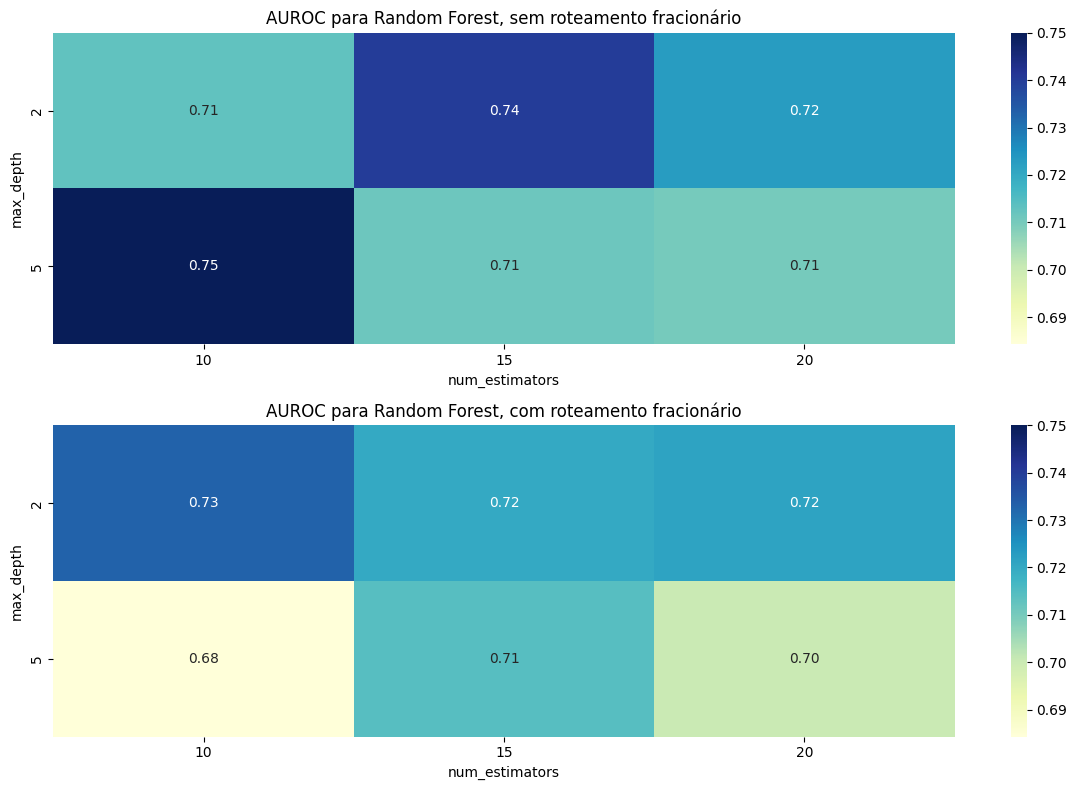

In [16]:
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

res = results_df[results_df['min_samples'] == 2]
vmax = res['AUROC'].max()
vmin = res['AUROC'].min()

base_heat_table = res[res['modelo'] == 'baseline'].pivot_table(index='max_depth', columns='num_estimators', values='AUROC')
sns.heatmap(base_heat_table, cmap="YlGnBu", ax=axs[0], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[0].set_title('AUROC para Random Forest, sem roteamento fracionário')

freq_heat_table = res[res['modelo'] == 'frequência'].pivot_table(index='max_depth', columns='num_estimators', values='AUROC')
sns.heatmap(freq_heat_table, cmap="YlGnBu", ax=axs[1], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[1].set_title('AUROC para Random Forest, com roteamento fracionário')

print('Resultados de AUROC com min_samples = 2')
plt.tight_layout()
plt.show()

Resultados de AUROC com min_samples = 5


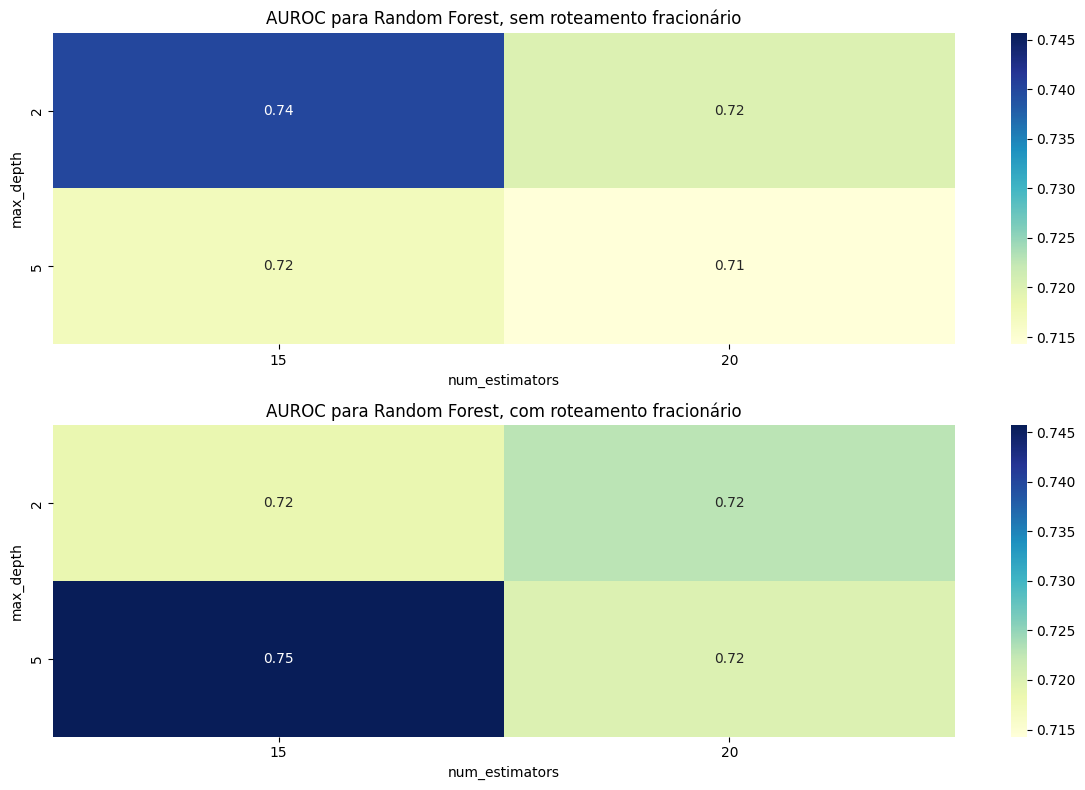

In [17]:
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

res = results_df[results_df['min_samples'] == 5]
vmax = res['AUROC'].max()
vmin = res['AUROC'].min()

base_heat_table = res[res['modelo'] == 'baseline'].pivot_table(index='max_depth', columns='num_estimators', values='AUROC')
sns.heatmap(base_heat_table, cmap="YlGnBu", ax=axs[0], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[0].set_title('AUROC para Random Forest, sem roteamento fracionário')

freq_heat_table = res[res['modelo'] == 'frequência'].pivot_table(index='max_depth', columns='num_estimators', values='AUROC')
sns.heatmap(freq_heat_table, cmap="YlGnBu", ax=axs[1], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[1].set_title('AUROC para Random Forest, com roteamento fracionário')

print('Resultados de AUROC com min_samples = 5')
plt.tight_layout()
plt.show()

Resultados de Acurácia com min_samples = 2


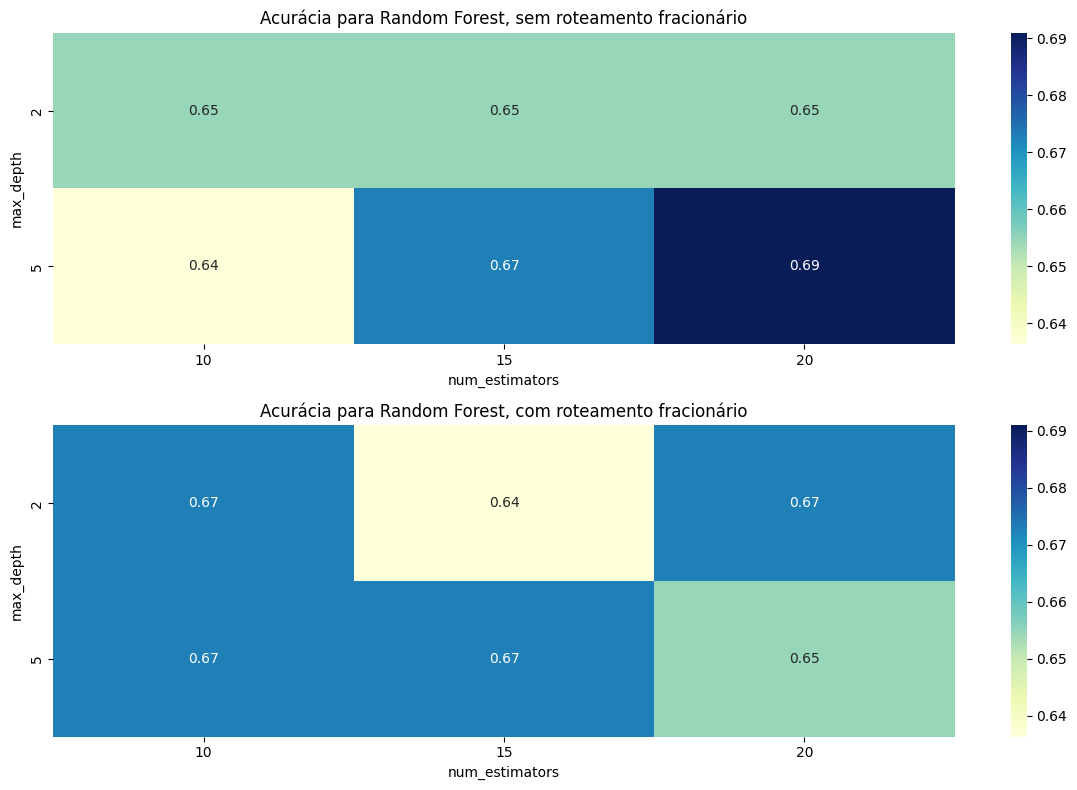

In [18]:
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

res = results_df[results_df['min_samples'] == 2]
vmax = res['Acurácia'].max()
vmin = res['Acurácia'].min()

base_heat_table = res[res['modelo'] == 'baseline'].pivot_table(index='max_depth', columns='num_estimators', values='Acurácia')
sns.heatmap(base_heat_table, cmap="YlGnBu", ax=axs[0], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[0].set_title('Acurácia para Random Forest, sem roteamento fracionário')

freq_heat_table = res[res['modelo'] == 'frequência'].pivot_table(index='max_depth', columns='num_estimators', values='Acurácia')
sns.heatmap(freq_heat_table, cmap="YlGnBu", ax=axs[1], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[1].set_title('Acurácia para Random Forest, com roteamento fracionário')

print('Resultados de Acurácia com min_samples = 2')
plt.tight_layout()
plt.show()

Resultados de Acurácia com min_samples = 5


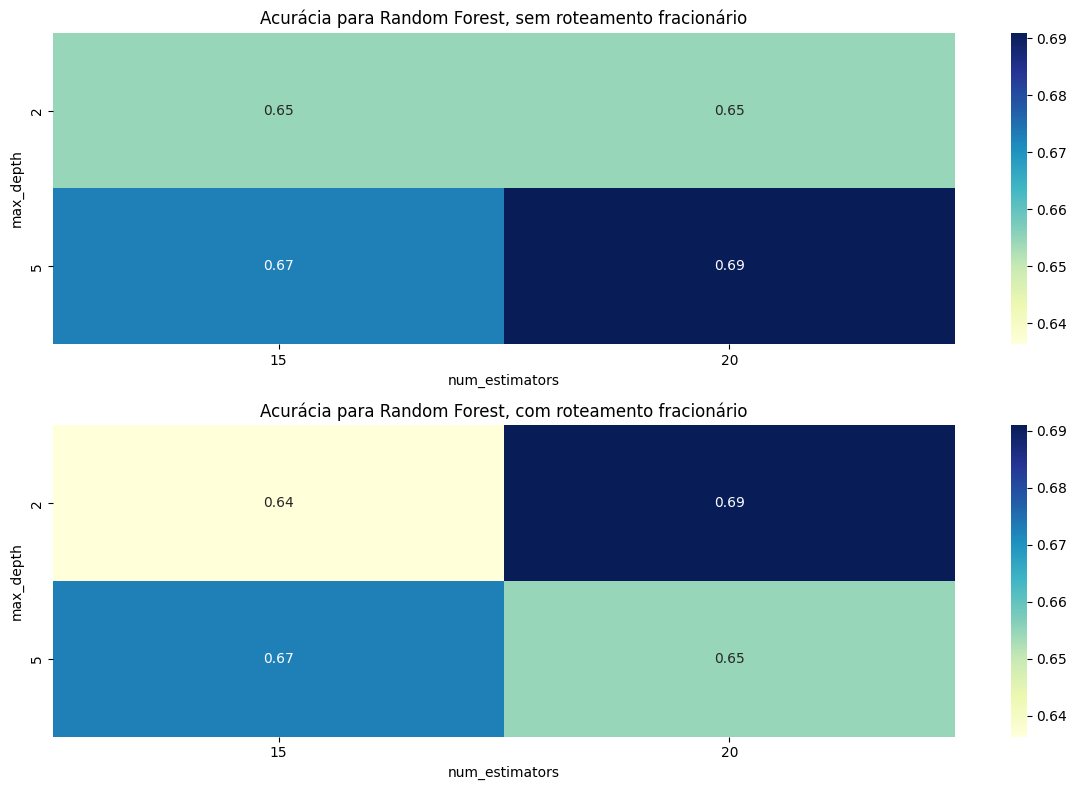

In [19]:
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

res = results_df[results_df['min_samples'] == 5]
vmax = res['Acurácia'].max()
vmin = res['Acurácia'].min()

base_heat_table = res[res['modelo'] == 'baseline'].pivot_table(index='max_depth', columns='num_estimators', values='Acurácia')
sns.heatmap(base_heat_table, cmap="YlGnBu", ax=axs[0], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[0].set_title('Acurácia para Random Forest, sem roteamento fracionário')

freq_heat_table = res[res['modelo'] == 'frequência'].pivot_table(index='max_depth', columns='num_estimators', values='Acurácia')
sns.heatmap(freq_heat_table, cmap="YlGnBu", ax=axs[1], vmin=vmin, vmax=vmax, annot=True, fmt='.2f')
axs[1].set_title('Acurácia para Random Forest, com roteamento fracionário')

print('Resultados de Acurácia com min_samples = 5')
plt.tight_layout()
plt.show()

In [20]:
base_best = results_df[results_df['modelo'] == 'baseline'].loc[results_df[results_df['modelo'] == 'baseline']['AUROC'].idxmax()]
base_best

modelo            baseline
min_samples              2
max_depth                5
num_estimators          10
AUROC                 0.75
Acurácia          0.636364
Name: 6, dtype: object

In [21]:
freq_best = results_df[results_df['modelo'] == 'frequência'].loc[results_df[results_df['modelo'] == 'frequência']['AUROC'].idxmax()]
freq_best

modelo            frequência
min_samples                5
max_depth                  5
num_estimators            15
AUROC               0.745714
Acurácia            0.672727
Name: 17, dtype: object

In [22]:
train_val_df = pd.concat([train_df, val_df], axis=0)
train_val_y = np.hstack([train_y, val_y])

base_best_f = RandomForest(min_samples=base_best.min_samples, max_depth=base_best.max_depth, regression=False)
base_best_f.fit(train_val_df[FEATURE_COLUMNS].values, train_val_y, num_feat_idx=num_feat_idx, 
                num_estimators=int(base_best.num_estimators), baseline=True, random_state=SEED)

freq_best_f = RandomForest(min_samples=freq_best.min_samples, max_depth=freq_best.max_depth, regression=False)
freq_best_f.fit(train_val_df[FEATURE_COLUMNS].values, train_val_y, num_feat_idx=num_feat_idx, 
                num_estimators=int(freq_best.num_estimators), baseline=False, random_state=SEED)

base_best_f_proba = base_best_f.predict_proba(test_df[FEATURE_COLUMNS].values)
base_best_f_preds = base_best_f.predict(test_df[FEATURE_COLUMNS].values)

freq_best_f_proba = freq_best_f.predict_proba(test_df[FEATURE_COLUMNS].values)
freq_best_f_preds = freq_best_f.predict(test_df[FEATURE_COLUMNS].values)

best_results = [{'modelo': 'baseline',
            'min_samples': base_best.min_samples,
            'max_depth': base_best.max_depth,
            'num_estimators': base_best.num_estimators,
            'AUROC val': base_best.AUROC,
            'AUROC teste': roc_auc_score(test_y, base_best_f_proba),
            'Acurácia': np.mean(test_y == base_best_f_preds)},
           {'modelo': 'frequência',
            'min_samples': freq_best.min_samples,
            'max_depth': freq_best.max_depth,
            'num_estimators': freq_best.num_estimators,
            'AUROC val': freq_best.AUROC,
            'AUROC teste': roc_auc_score(test_y, freq_best_f_proba),
            'Acurácia': np.mean(test_y == freq_best_f_preds)
            }]

best_results_df = pd.DataFrame(best_results)
best_results_df

,modelo,min_samples,max_depth,num_estimators,AUROC val,AUROC teste,Acurácia
0,baseline,2,5,10,0.750000,0.834014,0.75
1,frequência,5,5,15,0.745714,0.765986,0.75


<a id="K-Means"></a>
## Parte 2 - Agrupamento com K-means (valor: 40%)

Nesta parte, implemente K-means do zero usando os pontos artificiais abaixo. O objetivo é visualizar o movimento dos centroides e analisar a soma das distâncias quadradas.

Requisitos:

1. Use `K = 3`, `epsilon = 1e-4`, `max_iter = 150` e seed `13`.
2. Inicialize os centroides escolhendo `K` pontos do conjunto de dados sem reposição.
3. Em cada iteração:
   - atribua cada ponto ao centroide mais próximo usando distância euclidiana;
   - atualize cada centroide para a média dos pontos atribuídos ao cluster;
   - se um cluster não receber pontos, mantenha o centroide anterior desse cluster;
   - calcule e armazene a soma das distâncias quadradas.
4. Use a norma euclidiana do deslocamento conjunto dos centroides como critério de convergência. Pare quando ela for menor que `epsilon`.
5. Armazene o histórico de centroides, rótulos de cluster e soma das distâncias quadradas.
6. Plote 5 momentos determinísticos: estado inicial antes do aprendizado, estado final e três estados intermediários igualmente espaçados. Se houver menos de 5 estados, repita estados disponíveis sem inventar novas iterações.
7. Plote também a soma das distâncias quadradas ao longo das iterações.


In [23]:
K = 3
EPSILON = 1e-4
MAX_ITER = 150

np.random.seed(SEED)
num_samples = 200
num_features = 2
X = np.random.randn(num_samples, num_features) * 1.5 + np.array([[2, 2]])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 3 + np.array([[-5, -5]])])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 2 + np.array([[7, -5]])])

print(X.shape)


(600, 2)


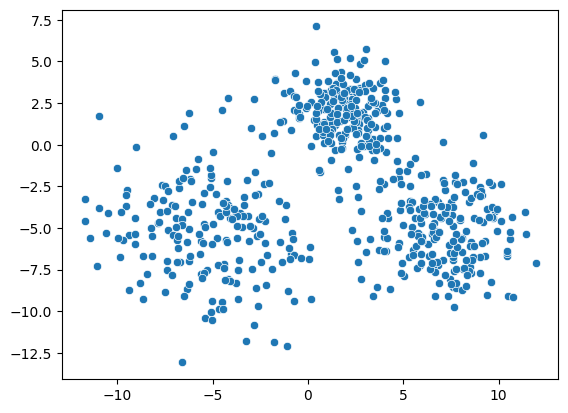

In [24]:
sns.scatterplot(x=X[:,0], y=X[:,1])
plt.show()

In [25]:
# Escreva aqui sua implementação de K-means, os gráficos dos 5 momentos
# e o gráfico da soma das distâncias quadradas.

class K_means_cluster:
	def __init__(self, k=K, epsilon=EPSILON, epochs=MAX_ITER, log_size=5, random_state=SEED):
		self.k = k
		self.epsilon = epsilon
		self.epochs = epochs
		self.log_size = log_size
		self.rng = np.random.default_rng(random_state)

	def cluster(self, X):
		self.X_modelo = X.copy()
		n_points = self.X_modelo.shape[0]
		centroides_idx = self.rng.choice(n_points, size=self.k, replace=False)
		centroides = self.X_modelo[centroides_idx, :]

		self.log_centroides = []
		self.log_sosd = []
		for e in range(self.epochs):
			self.log_centroides.append({'centroides': centroides.copy(), 'iter': e})

			diff = self.X_modelo[:, None, :] - centroides[None, :, :]
			dist = np.linalg.norm(diff, axis=-1)
			closest = np.argmin(dist, axis=1)

			new_centroides = np.zeros_like(centroides)
			sosd = 0
			for i in range(self.k):
				cluster = self.X_modelo[closest == i]
				if len(cluster) == 0:
					new_centroides[i] = centroides[i]
				else:
					new_centroides[i] = cluster.mean(axis=0) # mean retorna NaN se cluster for (0, d)

				sosd += np.sum((cluster - centroides[i])**2, axis=1).sum()
				
			self.log_sosd.append({'SoSD': sosd, 'Iter': e})
			
			dist_centroides = np.linalg.norm((new_centroides - centroides), axis=1)
			centroides = new_centroides

			if (dist_centroides.sum() < self.epsilon):
				break

		diff = self.X_modelo[:, None, :] - centroides[None, :, :]
		dist = np.linalg.norm(diff, axis=-1)
		closest = np.argmin(dist, axis=1)

		sosd = 0
		for i in range(self.k):
			cluster = self.X_modelo[closest == i]
			sosd += np.sum((cluster - centroides[i])**2, axis=1).sum()
		self.log_sosd.append({'SoSD': sosd, 'Iter': e+1})
		self.log_centroides.append({'centroides': centroides, 'iter': e+1})
		return closest

	def show_log(self):
		log_interval = np.ceil(len(self.log_centroides) / self.log_size).astype(int)

		fig, axs = plt.subplots(1, self.log_size, figsize=(3*self.log_size, 4))

		for i in range(self.log_size):
			if i != self.log_size-1:
				iter = i * log_interval
			else: 
				iter = -1

			centroides = self.log_centroides[iter]['centroides']
			diff = self.X_modelo[:, None, :] - centroides[None, :, :]
			dist = np.linalg.norm(diff, axis=-1)
			closest = np.argmin(dist, axis=1)

			clusters = np.array([f'Cluster {i}' for i in np.unique(closest)])
			sns.scatterplot(x=self.X_modelo[:, 0], y=self.X_modelo[:, 1], hue=clusters[closest], palette='YlGnBu', ax=axs[i])
			sns.scatterplot(x=centroides[:, 0], y=centroides[:, 1], color='black', marker='x', s=75, linewidth=3, ax=axs[i], label='Centródes')

			axs[i].grid(True)
			axs[i].set_title(f"Iteração: {self.log_centroides[iter]['iter']}")
			axs[i].set_ylabel('')
			axs[i].set_xlabel('')

		fig.tight_layout()
		plt.show()

		fig, axs = plt.subplots(1, 1, figsize=(8, 6))

		sns.lineplot(pd.DataFrame(self.log_sosd), x='Iter', y='SoSD', ls='--', marker='o', ax=axs)
		axs.set_title('Sum of Square Distances vs. Iteration')
		axs.set_ylabel('Sum of Square Distances')
		axs.set_xlabel('Iteration')
		axs.grid(True)

		fig.tight_layout()
		plt.show()
		

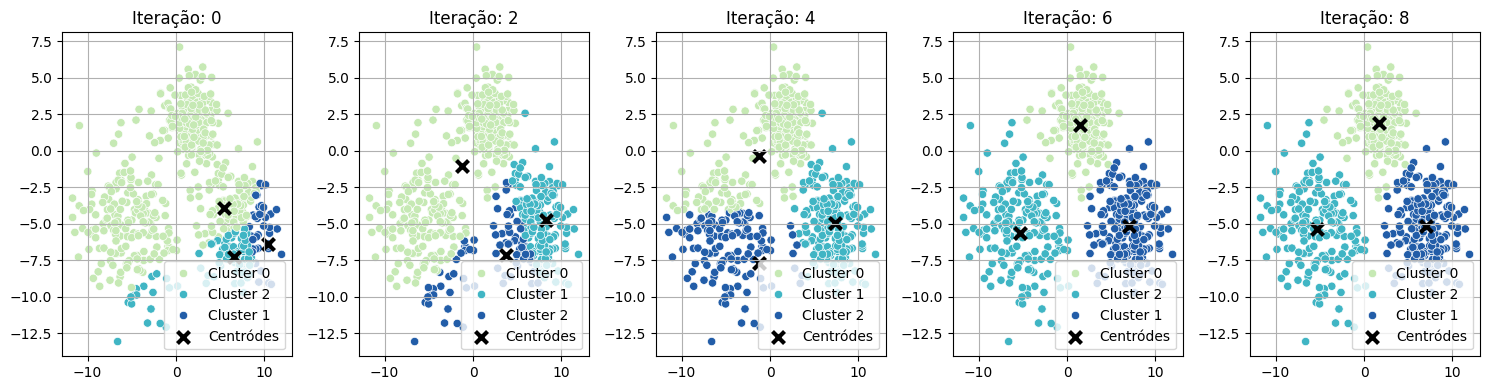

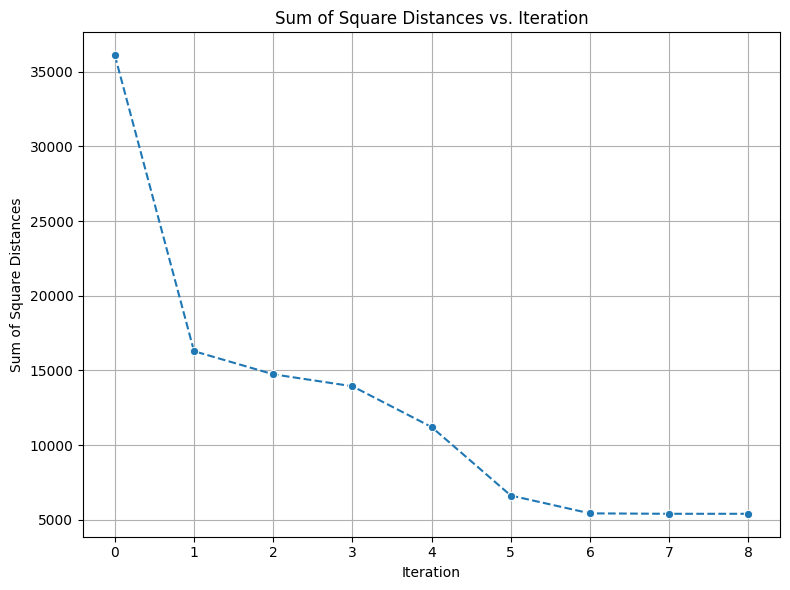

In [26]:
k_cls = K_means_cluster()
classified = k_cls.cluster(X)
k_cls.show_log()